<a href="https://colab.research.google.com/github/santillanfaiht-ops/FUNDAI-Lab1/blob/main/Lab6_Naive_Bayes_Santillan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6: Naive Bayes Classifier from Scratch and with Scikit-Learn

## Fundamentals of Artificial Intelligence

**Name:** Santillan FAith Angela U.
**Course:** BSCS-AI
**Section:** 2A
**Date:** October 1, 2026

**DataSet Source:**

**Github URL:** https://github.com/santillanfaiht-ops/FUNDAI-Lab1.git

## Description
This labaratory implements a Naive Bayes classififer from scratch and compares it with the Scikit-learn implementation. The dataset is loaded directly from GitHub.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB, CategoricalNB

## Loading the Dataset from GitHub

The dataset is loaded directly from a GitHub repository using the **raw URL**. A normal GitHub webpage (blob) URL will not work with 'pd.read_csv()'.


In [6]:
GITHUB_RAW_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

df = pd.read_csv(GITHUB_RAW_URL)

print("Dataset shape:", df.shape)
print()
print(df.head())
print()
print("Class distribution:")
print(df["species"].value_counts())

Dataset shape: (150, 5)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [8]:
feature_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

X = df[feature_columns].values
y = df["species"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (105, 4)
Testing samples: (45, 4)


## From-Scratch Gaussasian Naive Bayes

The classifier uses:

- Prior probability: P(class)
- Gaussian likelihood: P(feature | class)
- Log-posterior: log P(class) + sum  of log likelihoods

Log probabilities are used to avoid numerical underflow.



In [18]:
class GaussianNaiveBayesScratch:
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        self.priors_ = {}
        self.means_ = {}
        self.variances_ = {}

        total_samples = len(y)

        for c in self.classes_:
            X_c = X[y == c]

            self.priors_[c] = len(X_c) / total_samples
            self.means_[c] = X_c.mean(axis=0)
            self.variances_[c] = X_c.var(axis=0) + self.var_smoothing

        return self

    def _log_likelihood(self, x, c):
        mu = self.means_[c]
        var = self.variances_[c]

        term1 = -0.5 * np.sum(np.log(2 * np.pi * var))
        term2 = -0.5 * np.sum(((x - mu) ** 2) / var)

        return term1 + term2

    def _log_posterior(self, x, c):
        return np.log(self.priors_[c]) + self._log_likelihood(x, c)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        predictions = []

        for x in X:
            scores = {
                c: self._log_posterior(x, c)
                for c in self.classes_
            }
            best_class = max(scores, key=scores.get)
            predictions.append(best_class)

        return np.array(predictions)

In [19]:
scratch_model = GaussianNaiveBayesScratch()
scratch_model.fit(X_train, y_train)

scratch_predictions = scratch_model.predict(X_test)
scratch_accuracy = accuracy_score(y_test, scratch_predictions)

print("From-Scratch Gaussian Naive Bayes")
print("-" * 50)
print("Accuracy:", scratch_accuracy)
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, scratch_predictions))
print()
print(classification_report(y_test, scratch_predictions))

From-Scratch Gaussian Naive Bayes
--------------------------------------------------
Accuracy: 0.9111111111111111

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



## Scikit-learn GaussianNB

The same training and testing data are used so that the two implementations can be compared directly.

In [20]:
sklearn_model = GaussianNB()
sklearn_model.fit(X_train, y_train)

sklearn_predictions = sklearn_model.predict(X_test)
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)

print("Scikit-learn GaussianNB")
print("-" * 50)
print("Accuracy:", sklearn_accuracy)
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, sklearn_predictions))
print()
print(classification_report(y_test, sklearn_predictions))

Scikit-learn GaussianNB
--------------------------------------------------
Accuracy: 0.9111111111111111

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [21]:
agreement = np.mean(scratch_predictions == sklearn_predictions)

print("Implementation Comparison")
print("-" * 50)
print("From-scratch accuracy :", scratch_accuracy)
print("Scikit-learn accuracy :", sklearn_accuracy)
print("Prediction agreement :", agreement)
print()
print("From-scratch priors:")
print(scratch_model.priors_)
print("Scikit-learn priors:")
print(dict(zip(sklearn_model.classes_, sklearn_model.class_prior_)))

Implementation Comparison
--------------------------------------------------
From-scratch accuracy : 0.9111111111111111
Scikit-learn accuracy : 0.9111111111111111
Prediction agreement : 1.0

From-scratch priors:
{'setosa': 0.3333333333333333, 'versicolor': 0.3333333333333333, 'virginica': 0.3333333333333333}
Scikit-learn priors:
{np.str_('setosa'): np.float64(0.3333333333333333), np.str_('versicolor'): np.float64(0.3333333333333333), np.str_('virginica'): np.float64(0.3333333333333333)}


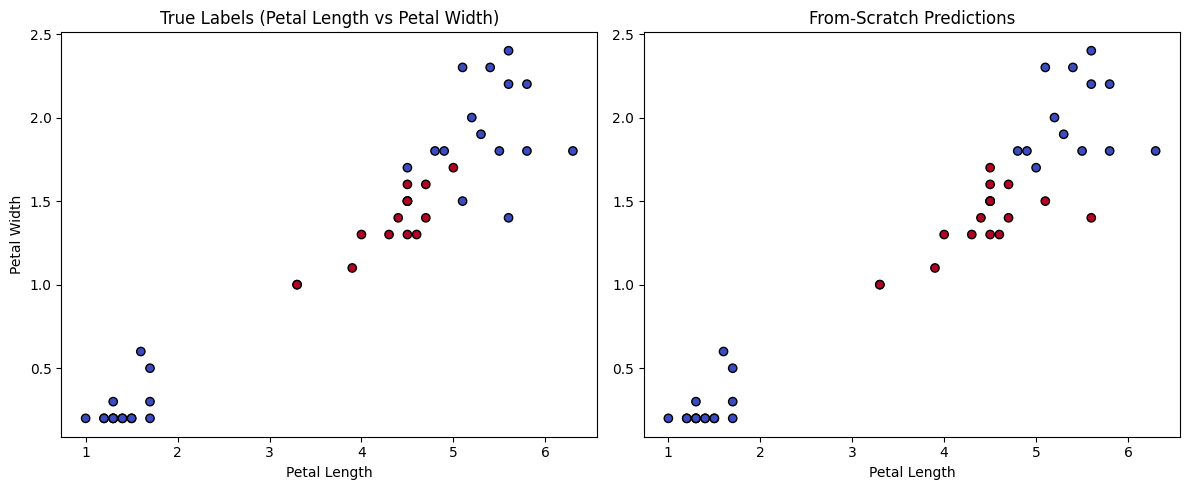

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(
    X_test[:, 2],
    X_test[:, 3],
    c=(y_test == "versicolor").astype(int),
    cmap="coolwarm",
    edgecolor="k"
)
plt.title("True Labels (Petal Length vs Petal Width)")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.subplot(1, 2, 2)
plt.scatter(
    X_test[:, 2],
    X_test[:, 3],
    c=(scratch_predictions == "versicolor").astype(int),
    cmap="coolwarm",
    edgecolor="k"
)
plt.title("From-Scratch Predictions")
plt.xlabel("Petal Length")

plt.tight_layout()
plt.show()

## Categorical Naive Bayes with Laplace Smoothing

Numeric features are converted into discrete bins using training-data bin edges. Laplace (add-one) smoothing prevents zero probabilities

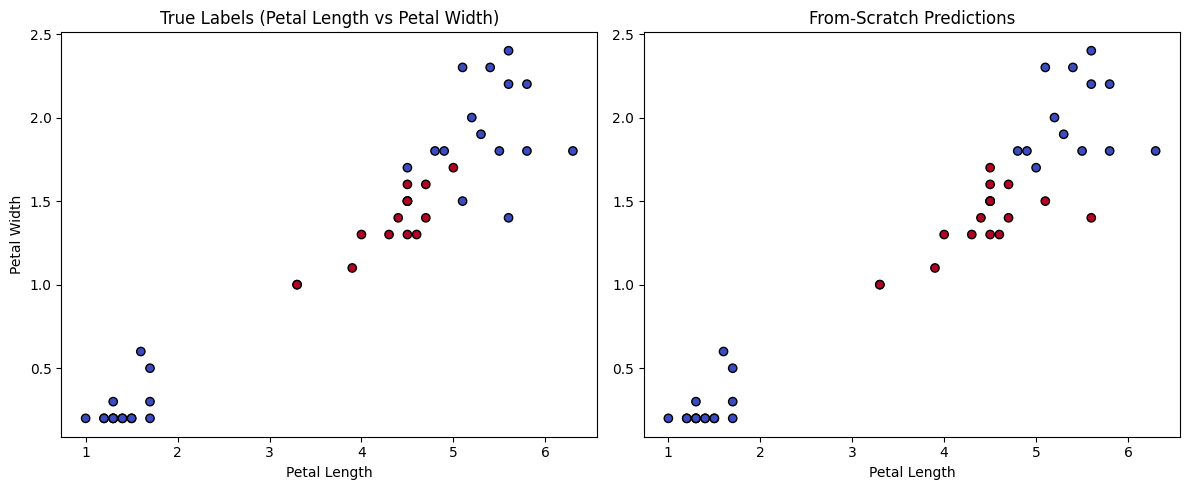

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(
    X_test[:, 2],
    X_test[:, 3],
    c=(y_test == "versicolor").astype(int),
    cmap="coolwarm",
    edgecolor="k"
)
plt.title("True Labels (Petal Length vs Petal Width)")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.subplot(1, 2, 2)
plt.scatter(
    X_test[:, 2],
    X_test[:, 3],
    c=(scratch_predictions == "versicolor").astype(int),
    cmap="coolwarm",
    edgecolor="k"
)
plt.title("From-Scratch Predictions")
plt.xlabel("Petal Length")

plt.tight_layout()
plt.show()